<a href="https://colab.research.google.com/github/marymuthee/Masters_portoflio/blob/main/ship_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automatic Detection of Ship Containers using Segment Anything Model (SAM)**

Port container monitoring is a critical task in logistics, customs control, and urban planning. Manually counting and mapping shipping containers from aerial imagery is time-consuming and error-prone, especially at large port facilities handling thousands of containers simultaneously. This notebook presents an automated, annotation-free pipeline for detecting and counting shipping containers using a combination of high-resolution RGB orthophoto imagery and LiDAR point cloud data.

The pipeline leverages the Segment Anything Model (SAM) developed by Meta AI Research as its core detection engine, combined with LiDAR-derived height filtering to eliminate false positives and isolate elevated objects (containers) from ground-level features.

Unlike supervised deep learning approaches that require thousands of annotated training samples, this pipeline operates without any manual annotation, making it highly transferable to new port scenes and scalable to large datasets.

## **Segment Anything Model (SAM)**

SAM is a foundation model for image segmentation developed by Meta AI Research, released in 2023. It is capable of segmenting any object in any image, zero-shot without task-specific training. SAM accepts optional prompts (points, boxes, or text) but can also operate in fully automatic mode, generating masks for all identifiable objects in an image.



*  Paper: Segment Anything -https://arxiv.org/abs/2304.02643
*   GitHub: https://github.com/facebookresearch/segment-anything

## **Dataset**

The dataset consists of two co-registered data sources covering the same 500m × 500m
port area, acquired on the same date. Both datasets share the same coordinate reference
system (EPSG:32631 — WGS84 / UTM Zone 31N).

| Parameter             | RGB Orthophoto                                      | LiDAR Point Cloud                                        |
|-----------------------|-----------------------------------------------------|----------------------------------------------------------|
| **File**              | BE_ORTHO_27032011_315130_56865_UTM31N.tif           | BE_LIDAR_27032011_315130_56865_UTM31N.las                |
| **Acquisition Date**  | 27 March 2011                                       | 27 March 2011                                            |
| **Coverage**          | 500m × 500m                                         | 500m × 500m                                             |
| **Resolution**        | 5cm GSD                                             | ~20M points (≈ 25cm spacing)                            |
| **Image/Point Size**  | 10,000 × 10,000 pixels                              | 20,022,938 points                                        |
| **Spectral/Attributes**| 3 bands (RGB), uint8                               | X, Y, Z, Intensity, RGB, Return Number                  |
| **Coordinate System** | EPSG:32631 — WGS84 / UTM Zone 31N                  | EPSG:32631 — WGS84 / UTM Zone 31N                       |
                             


> **Note:** A DSM file was provided for the same scene but was **not used** in this
> pipeline, as it excludes mobile objects (containers, vehicles, vessels) by design.
> The raw LiDAR point cloud was used instead, as it captures all objects
> present at the time of acquisition.

## **Environment Setup**
This pipeline runs entirely in **Google Colab** using a free GPU runtime (NVIDIA T4).
All data is loaded directly from **Google Drive**

###  **Requirements**

| Library            | Purpose                                              |
|--------------------|------------------------------------------------------|
| `segment-anything` | Meta's SAM model for automatic mask generation       |
| `rasterio`         | Read/write GeoTIFF orthophoto with georeferencing    |
| `laspy`            | Read LiDAR point cloud (.las format)                 |
| `numpy`            | Array operations and mask creation                   |
| `opencv-python`    | Rotated bounding box fitting and morphological ops   |
| `matplotlib`       | Visualization of detections at each pipeline stage   |
| `geopandas`        | Spatial data handling                                |
| `shapely`          | Geometry operations                                  |
| `torch`            | PyTorch backend for SAM inference                    |







###  **Libraries Installation**

In [3]:
# Install required libraries
#!pip install segment-anything rasterio laspy[lazrs] geopandas shapely -q

# Download SAM pretrained weights (ViT-B variant, ~375MB)
#!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

#print("All dependencies installed")
#print("SAM weights downloaded")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


### **Mount Google Drive**

In [2]:
#mount drive
from google.colab import drive
drive.mount(  '/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Data Loading and Inspection**

### **Libraries**

In [3]:
#call libraries
import rasterio #raster data
import geopandas as gpd #vector data
import shapely #geometry objects for spatial operation
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
import cv2  #computer vision for rotating the bounding boxes
import laspy  #for working with eth lidar data

### **Data loading**

In [4]:
#image path
image_path="/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif" #from my drive
print("File exists:", os.path.exists(image_path))  #check if the file exists
print("File size:", round(os.path.getsize(image_path) / 1024 / 1024, 2), "MB")  #check size

File exists: True
File size: 184.66 MB


In [5]:
#read image from path
#check crs, widthmheight, bands
with rasterio.open(image_path) as src:
    print("CRS:", src.crs)
    print("Width:", src.width, "px")
    print("Height:", src.height, "px")
    print("Bands:", src.count)
    print("Dtype:", src.dtypes[0])
    print("Resolution (m/px):", src.res)

CRS: EPSG:32631
Width: 10000 px
Height: 10000 px
Bands: 3
Dtype: uint8
Resolution (m/px): (0.05, 0.05)


### **Plot Image**

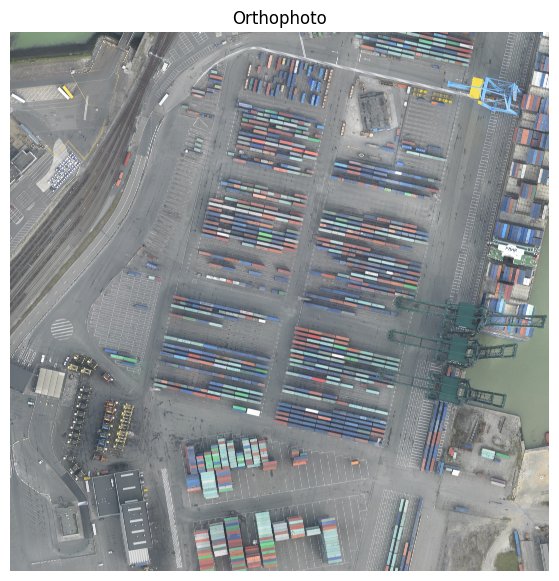

In [82]:
with rasterio.open(image_path) as src:
    img = src.read([1, 2, 3])  # Read RGB bands

# Rasterio reads as (bands, height, width) ,convert to (height, width, bands)
img = np.moveaxis(img, 0, -1)

plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.title("Orthophoto")
plt.axis('off')
plt.show()

## **SAM Segmentation**

Since the orthophoto is 10,000 × 10,000 pixels (500m × 500m at 5cm GSD), it is far too
large to process in a single pass SAM would exceed available GPU memory on Google Colab.
To address this, the image is divided into a **5×5 grid of zones**, each processed
independently and saved to Google Drive immediately after completion. This approach is
**crash-safe and resumable** if the session disconnects, processing continues from
where it left off.

Within each zone, a further **tiling strategy** is applied to fit within SAM's memory
constraints. Detected masks are converted to **oriented (rotated) bounding boxes** using
OpenCV's `minAreaRect()`, which fits a tight rectangle matching the actual angle of each
object  critical for containers which are not axis-aligned in the image.

At the end of this section, the raw SAM output contains **~19,759 candidate segments**
covering containers, vehicles, buildings, roads, and other port features. Subsequent
sections apply LiDAR height filtering and shape-based filtering to isolate containers only.

### Tiled Inference Strategy

To handle the large image size while staying within GPU memory limits, the following
tiling strategy is applied:

| Parameter        | Value                        | Rationale                              |
|------------------|------------------------------|----------------------------------------|
| **Grid**         | 5 × 5 = 25 zones             | Divides full image into manageable areas|
| **Zone Size**    | 2,000 × 2,000 px (100m×100m) | Small enough for reliable SAM output  |
| **Tile Size**    | 512 × 512 px                 | Standard SAM inference resolution     |
| **Tile Overlap** | 50 px                        | Prevents missing objects at tile edges |
| **Skip Threshold**| std < 15                    | Skips uniform gray tiles (empty ground)|
| **Output Format**| Rotated bounding box (.pkl)  | Oriented box fits actual container angle|

Each zone result is saved as a `.pkl` file to Google Drive immediately after processing,
ensuring no progress is lost in case of session disconnection.

In [23]:
#import libarraies
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

#clear GPU memory
torch.cuda.empty_cache()

#load SAM ViT-B pretrained model
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

#model configuration
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    min_mask_region_area=500,
)

#image path
image_path = '/content/drive/MyDrive/Eo_Project/BE_ORTHO_27032011_315130_56865_UTM31N.tif'
save_dir = '/content/drive/MyDrive/Eo_Project/zones/'  #save the zones here
os.makedirs(save_dir, exist_ok=True)

#the tiling parameters
ZONE_SIZE = 2000
TILE_SIZE = 512
OVERLAP = 50
GRID = 5  # 5x5


#tiling loops
for row in range(GRID):
    for col in range(GRID):
        zone_name = f"zone_r{row}_c{col}"
        save_path = f"{save_dir}{zone_name}.pkl"

        # Skip if already processed
        if os.path.exists(save_path):
            print(f"Skipping {zone_name} ")
            continue

        row_off = row * ZONE_SIZE
        col_off = col * ZONE_SIZE

        print(f"\n=== Processing {zone_name} (row={row}, col={col}) ===")
        zone_boxes = []
        tile_count = 0

        with rasterio.open(image_path) as src:
            window = rasterio.windows.Window(col_off, row_off, ZONE_SIZE, ZONE_SIZE)
            zone_img = src.read([1, 2, 3], window=window)  #read te zones rgb band from the image
            zone_img = np.moveaxis(zone_img, 0, -1)

        h, w = zone_img.shape[:2]

        for y in range(0, h, TILE_SIZE - OVERLAP):
            for x in range(0, w, TILE_SIZE - OVERLAP):
                x_end = min(x + TILE_SIZE, w)
                y_end = min(y + TILE_SIZE, h)
                tile = zone_img[y:y_end, x:x_end]


                if tile.shape[0] < 64 or tile.shape[1] < 64:
                    continue

                # Skip empty/gray tiles (empty areas , roads etc)
                if np.std(np.mean(tile, axis=2)) < 15:
                    continue

                #RUN  same on each tile

                tile_masks = mask_generator.generate(tile)

                for mask in tile_masks:
                    m = mask['segmentation'].astype(np.uint8)
                    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                    if not contours:
                        continue
                    cnt = max(contours, key=cv2.contourArea)
                    rect = cv2.minAreaRect(cnt)

                    (cx, cy), (bw, bh), angle = rect
                    # Offset to full image coordinates
                    cx += col_off + x
                    cy += row_off + y
                    rect_global = ((cx, cy), (bw, bh), angle)

                     # Store box with shape attributes for later filtering

                    if min(bw, bh) > 0:
                        zone_boxes.append({
                            'rect': rect_global,
                            'area': mask['area'],
                            'aspect_ratio': max(bw, bh) / min(bw, bh),
                            'box_w': bw,
                            'box_h': bh
                        })

                tile_count += 1
                del tile_masks
                torch.cuda.empty_cache()

        # Save zone immediately
        with open(save_path, 'wb') as f:
            pickle.dump(zone_boxes, f)
        print(f"{zone_name} done — {len(zone_boxes)} boxes saved ")
        del zone_img
        torch.cuda.empty_cache()
print("\nAll zones done! ")

Skipping zone_r0_c0 
Skipping zone_r0_c1 
Skipping zone_r0_c2 
Skipping zone_r0_c3 
Skipping zone_r0_c4 

=== Processing zone_r1_c0 (row=1, col=0) ===
zone_r1_c0 done — 1018 boxes saved 

=== Processing zone_r1_c1 (row=1, col=1) ===
zone_r1_c1 done — 446 boxes saved 

=== Processing zone_r1_c2 (row=1, col=2) ===
zone_r1_c2 done — 808 boxes saved 

=== Processing zone_r1_c3 (row=1, col=3) ===
zone_r1_c3 done — 765 boxes saved 

=== Processing zone_r1_c4 (row=1, col=4) ===
zone_r1_c4 done — 977 boxes saved 

=== Processing zone_r2_c0 (row=2, col=0) ===
zone_r2_c0 done — 704 boxes saved 

=== Processing zone_r2_c1 (row=2, col=1) ===
zone_r2_c1 done — 802 boxes saved 

=== Processing zone_r2_c2 (row=2, col=2) ===
zone_r2_c2 done — 688 boxes saved 

=== Processing zone_r2_c3 (row=2, col=3) ===
zone_r2_c3 done — 539 boxes saved 

=== Processing zone_r2_c4 (row=2, col=4) ===
zone_r2_c4 done — 1111 boxes saved 

=== Processing zone_r3_c0 (row=3, col=0) ===
zone_r3_c0 done — 1260 boxes saved 



### **Loading and combinig zones results**

Once all 25 zones have been processed, the individual `.pkl` files are loaded
and combined into a single list of candidate boxes. This gives us the complete
raw SAM output across the full 10,000 × 10,000px image, ready for filtering.

In [81]:
import pickle
import os

save_dir = '/content/drive/MyDrive/Eo_Project/zones/'  #zones directory

all_boxes = []  #create an empty lizt to store th eboxes
total_zones = 0

for row in range(5):
    for col in range(5):
        zone_name = f"zone_r{row}_c{col}"
        save_path = f"{save_dir}{zone_name}.pkl"

        if os.path.exists(save_path):
            with open(save_path, 'rb') as f:
                zone_boxes = pickle.load(f)
            print(f"{zone_name}: {len(zone_boxes)} boxes ")
            all_boxes.extend(zone_boxes)
            total_zones += 1
        else:
            print(f"{zone_name}: NOT FOUND ")

print(f"\nZones loaded: {total_zones}/25")
print(f"Total boxes: {len(all_boxes)}")
rotated_boxes = all_boxes

zone_r0_c0: 705 boxes 
zone_r0_c1: 855 boxes 
zone_r0_c2: 1057 boxes 
zone_r0_c3: 980 boxes 
zone_r0_c4: 1048 boxes 
zone_r1_c0: 1018 boxes 
zone_r1_c1: 446 boxes 
zone_r1_c2: 808 boxes 
zone_r1_c3: 765 boxes 
zone_r1_c4: 977 boxes 
zone_r2_c0: 704 boxes 
zone_r2_c1: 802 boxes 
zone_r2_c2: 688 boxes 
zone_r2_c3: 539 boxes 
zone_r2_c4: 1111 boxes 
zone_r3_c0: 1260 boxes 
zone_r3_c1: 873 boxes 
zone_r3_c2: 728 boxes 
zone_r3_c3: 1054 boxes 
zone_r3_c4: 648 boxes 
zone_r4_c0: 480 boxes 
zone_r4_c1: 666 boxes 
zone_r4_c2: 639 boxes 
zone_r4_c3: 427 boxes 
zone_r4_c4: 481 boxes 

Zones loaded: 25/25
Total boxes: 19759


##  **Lidar for Filtering**


The raw SAM output contains **19,759 candidate segments** covering all visible objects
in the orthophoto containers, vehicles, buildings, cranes, roads, and ground markings.
To isolate containers from this noisy output, we leverage the **LiDAR point cloud**
acquired simultaneously with the orthophoto.

LiDAR provides the **absolute 3D elevation (Z)** of every scanned point. Since containers
are physical objects elevated above the ground, they occupy a distinct height range that
can be used as a reliable filter:

| Object Type         | Approximate Z Range (absolute) |
|---------------------|-------------------------------|
| Ground / Roads      | ~49.9m                        |
| Vehicles / Trucks   | 50.5m – 51.5m                 |
| Yard Containers     | 51.5m – 63m                   |
| Stacked Containers  | 63m – 80m                     |
| Ship Containers     | 62m – 90m                     |
| Cranes / Structures | 90m – 193m                    |

> **Important:** The LiDAR point cloud used here is the **raw unclassified dataset**
> (Class 0). The DSM provided for the same scene was not used, as it explicitly
> excludes mobile objects such as containers and vehicles by design.

The filtering approach works as follows:
1. Load the LiDAR `.las` file and extract X, Y, Z coordinates
2. Filter points within the container height range **(51.5m – 90m)**
3. Rasterize filtered points onto a **10,000 × 10,000 binary mask**
   aligned with the orthophoto grid
5. Keep only SAM boxes whose **center pixel falls within the mask**

### **Data Loading**

In [35]:
import laspy
import numpy as np

las_path = '/content/drive/MyDrive/Eo_Project/BE_LIDAR_27032011_315130_56865_UTM31N.las' #read file from drive

las = laspy.read(las_path)

print("LiDAR file loaded")
print(f"Number of points: {len(las.points):,}")
print(f"CRS/VLRs: {las.header.vlrs}")
print(f"\nPoint attributes: {list(las.point_format.dimension_names)}")


LiDAR file loaded
Number of points: 20,022,938
CRS/VLRs: [<GeoKeyDirectoryVlr(3 geo_keys)>, <GeoAsciiParamsVlr(['WGS 84 / UTM zone 31N'])>]

Point attributes: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'gps_time', 'red', 'green', 'blue']


In [36]:
# Convert to numpy arrays
x = np.array(las.x)
y = np.array(las.y)
z = np.array(las.z)
classification = np.array(las.classification)

print(f"Z mean: {z.mean():.2f}m")
print(f"Z std:  {z.std():.2f}m")

# Check classifications
unique_classes, counts = np.unique(classification, return_counts=True)
print(f"\nPoint classifications:")
for c, n in zip(unique_classes, counts):
    print(f"  Class {c}: {n:,} points")

# Check Z distribution
percentiles = np.percentile(z, [1, 5, 25, 50, 75, 95, 99])
print(f"\nZ percentiles:")
labels = ['1%', '5%', '25%', '50%', '75%', '95%', '99%']
for l, p in zip(labels, percentiles):
    print(f"  {l}: {p:.2f}m")

Z mean: 52.68m
Z std:  8.98m

Point classifications:
  Class 0: 20,022,938 points

Z percentiles:
  1%: 44.06m
  5%: 48.77m
  25%: 49.70m
  50%: 49.91m
  75%: 50.33m
  95%: 66.76m
  99%: 99.51m


### **Lidar heigh exploration**



Before building the height mask, a sample area of 200m × 200m is extracted
from the point cloud and visualised coloured by elevation. This confirms the
Z distribution across the scene and helps identify the correct height thresholds
for container detection.

The  plot is saved to Google Drive for reference.

In [50]:
import numpy as np
import matplotlib.pyplot as plt

#pick a certain area within the AOi

x_min, x_max = 513150, 513350
y_min, y_max = 5686650, 5686850

#extract points within the sample area
area = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
x_a = x[area]
y_a = y[area]
z_a = z[area]

print(f"Points in area: {len(z_a):,}")
print(f"Z range: {z_a.min():.2f} → {z_a.max():.2f}")

#plot and save
plt.figure(figsize=(12, 10))
sc = plt.scatter(x_a, y_a, c=z_a, cmap='RdYlGn', s=0.5, vmin=49, vmax=62)
plt.colorbar(sc, label='Height (m)')
plt.title("Raw LiDAR points colored by height\nGreen=ground, Red=elevated")
plt.axis('equal')
plt.savefig('/content/drive/MyDrive/Eo_Project/lidar_points_raw.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved ")

Points in area: 3,206,297
Z range: 49.50 → 102.49
Saved 


### Filter within the ship containers area

In [74]:
import laspy
import numpy as np
import rasterio

# Reload LiDAR
las = laspy.read('/content/drive/MyDrive/Eo_Project/BE_LIDAR_27032011_315130_56865_UTM31N.las')
x = np.array(las.x)
y = np.array(las.y)
z = np.array(las.z)

print(f"LiDAR bounds:")
print(f"X: {x.min():.1f} → {x.max():.1f}")
print(f"Y: {y.min():.1f} → {y.max():.1f}")

#this is done to identify the correct heigh threshold to use

# From transform:
# X = 513000 + col * 0.05  -> col = (X - 513000) / 0.05
# Y = 5687000 + row * (-0.05) -> row = (5687000 - Y) / 0.05

# Ship is at pixel x:9000-10000, y:1000-6000
# Convert to geo:
x_min_geo = 513000 + 9000 * 0.05   # 513450
x_max_geo = 513000 + 10000 * 0.05  # 513500
y_max_geo = 5687000 - 1000 * 0.05  # 5686950
y_min_geo = 5687000 - 6000 * 0.05  # 5686700

print(f"\nShip geo bounds:")
print(f"X: {x_min_geo:.1f} → {x_max_geo:.1f}")
print(f"Y: {y_min_geo:.1f} → {y_max_geo:.1f}")

# Get ship points
ship_pts = (x >= x_min_geo) & (x <= x_max_geo) & \
           (y >= y_min_geo) & (y <= y_max_geo)
z_ship = z[ship_pts]

print(f"\nLiDAR points in ship area: {len(z_ship):,}")
if len(z_ship) > 0:
    for p in [0, 5, 25, 50, 75, 90, 95, 99, 100]:
        print(f"  {p}%: {np.percentile(z_ship, p):.2f}m")

LiDAR bounds:
X: 513000.0 → 513500.0
Y: 5686500.0 → 5687000.0

Ship geo bounds:
X: 513450.0 → 513500.0
Y: 5686700.0 → 5686950.0

LiDAR points in ship area: 954,015
  0%: 43.13m
  5%: 44.05m
  25%: 49.87m
  50%: 62.81m
  75%: 76.52m
  90%: 80.05m
  95%: 88.49m
  99%: 132.17m
  100%: 149.47m


## **Build Container Height Mask**

A binary raster mask is created by projecting filtered LiDAR points onto the
orthophoto pixel grid. Two overlapping height ranges are combined to capture
both yard and ship containers:

| Container Type  | Height Range  | Reason                                      |
|-----------------|---------------|---------------------------------------------|
| Yard containers | 51.5m – 63m   | Port ground (~49.9m) + container height     |
| Ship containers | 62m – 90m     | Ship deck is higher than port ground level  |
| **Combined**    | **51.5m – 90m** | Single range covering all container types |

A **3×3 morphological dilation** (2 iterations) is applied to fill sparse gaps
on flat container rooftops, where LiDAR returns are less dense due to specular
reflection on metal surfaces. The resulting mask and a side-by-side visualisation
are saved to Google Drive for reference.

In [75]:
import numpy as np
import cv2
import rasterio
import matplotlib.pyplot as plt

# Two height ranges:
# Yard containers: 51.5 - 63m
# Ship containers: 62 - 90m (overlapping intentionally)
# Combined: 51.5 - 90m

GROUND_Z = 49.9
min_h = 51.5
max_h = 90.0  # extended to cover ship containers


#filter lidar points within the height ranges
mask = (z >= min_h) & (z <= max_h)
x_c = x[mask]
y_c = y[mask]

#load orthophoto spatial reference for pixel alignment
with rasterio.open(image_path) as src:
    transform = src.transform
    width = src.width
    height = src.height

#convert coordinates to pixel indices
col_idx = ((x_c - transform.c) / transform.a).astype(int)
row_idx = ((y_c - transform.f) / transform.e).astype(int)

#keep only points within image bounds
valid = (col_idx >= 0) & (col_idx < width) & (row_idx >= 0) & (row_idx < height)

#rasterize lidar points
container_mask = np.zeros((height, width), dtype=np.uint8)
container_mask[row_idx[valid], col_idx[valid]] = 1

# Mild dilation to fill anysparse gaps
kernel = np.ones((3, 3), np.uint8)
container_mask_final = cv2.dilate(container_mask, kernel, iterations=2)

print(f"Mask pixels: {container_mask_final.sum():,} ({container_mask_final.sum()/1e8*100:.1f}%)")

# Visualize
with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read([1,2,3], out_shape=(3, int(src.height*scale), int(src.width*scale)))
    img_vis = np.moveaxis(img_vis, 0, -1)

mask_vis = cv2.resize(container_mask_final, (img_vis.shape[1], img_vis.shape[0]), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(img_vis)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(mask_vis, cmap='hot')
axes[1].set_title(f"Extended mask (51.5-90m)\n({container_mask_final.sum()/1e6:.1f}M pixels, {container_mask_final.sum()/1e8*100:.1f}%)")
axes[1].axis('off')

plt.savefig('/content/drive/MyDrive/Eo_Project/lidar_mask_extended.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved  — check lidar_mask_extended.png")

np.save('/content/drive/MyDrive/Eo_Project/container_mask_final.npy', container_mask_final)

Mask pixels: 18,783,504 (18.8%)
Saved  — check lidar_mask_extended.png


## **Filtering Pipeline**

The raw SAM output contains many false positives  vehicles,
buildings, cranes, road markings, and ground features. Three sequential filters
are applied to isolate shipping containers:

| Step | Filter              | Purpose                                          | Boxes Remaining |
|------|---------------------|--------------------------------------------------|-----------------|
| Raw  | —                   | Raw SAM output                                   | 19,759          |
| 1    | LiDAR Height Mask   | Remove ground-level objects                      | ~5,784          |
| 2    | Shape Filter        | Remove non-rectangular/wrong-size objects        | ~2,101          |
| 3    | NMS                 | Remove duplicate detections from tile overlap    | ~1,790          |

> **Zone-specific shape filtering:** The port yard and ship areas have
> fundamentally different container appearances due to viewing geometry.
> Yard containers are viewed perfectly top-down, while ship containers are
> partially occluded and stacked at height. Separate thresholds are applied
> for each zone to account for this difference.

### **LiDAR Mask Filter**

Each SAM box is checked against the LiDAR height mask built earlier.
Only boxes whose **center pixel falls within the elevated mask area** are retained.
This single step removes ~14,000 false positives in one pass.

In [ ]:
import numpy as np
import cv2
import pickle
import os

# Reload all SAM boxes
save_dir = '/content/drive/MyDrive/Eo_Project/zones/'
all_boxes = []
for row in range(5):
    for col in range(5):
        path = f"{save_dir}zone_r{row}_c{col}.pkl"
        if os.path.exists(path):
            with open(path, 'rb') as f:
                all_boxes.extend(pickle.load(f))

print(f"Total SAM boxes: {len(all_boxes)}")

#  LiDAR filter with new mask
lidar_filtered = []
for b in all_boxes:
    cx, cy = int(b['rect'][0][0]), int(b['rect'][0][1])
    if 0 <= cx < 10000 and 0 <= cy < 10000:
        if container_mask_final[cy, cx] == 1:
            lidar_filtered.append(b)

print(f"After LiDAR filter: {len(lidar_filtered)}")

### **Zone-Specific Shape Filter**

Containers have a consistent rectangular shape with a high aspect ratio
(length >> width). Non-container objects (vehicles, buildings, cranes) tend
to be either too small, too large, or too square.

Two sets of thresholds are applied depending on location:

| Parameter       | Yard Containers | Ship Containers | Rationale                          |
|-----------------|-----------------|-----------------|------------------------------------|
| Min Area (px²)  | 3,000           | 300             | Ship containers appear smaller     |
| Max Area (px²)  | 150,000         | 80,000          | Prevent merged multi-container blobs|
| Min Aspect Ratio| 1.8             | 1.3             | Ship containers more square-looking|

In [ ]:
#  Zone specific shape filter
SHIP_X_MIN, SHIP_X_MAX = 9000, 10000
SHIP_Y_MIN, SHIP_Y_MAX = 1000, 6000

shape_filtered = []
for b in lidar_filtered:
    cx, cy = b['rect'][0]
    in_ship = SHIP_X_MIN < cx < SHIP_X_MAX and SHIP_Y_MIN < cy < SHIP_Y_MAX

    if in_ship:
        if b['area'] > 300 and b['area'] < 80000 and b['aspect_ratio'] > 1.3:
            shape_filtered.append(b)
    else:
        if b['area'] > 3000 and b['area'] < 150000 and b['aspect_ratio'] > 1.8:
            shape_filtered.append(b)

print(f"After shape filter: {len(shape_filtered)}")

###  **Non-Maximum Suppression (NMS)**

Because the image is processed in overlapping tiles, the same container can be
detected multiple times in adjacent tiles. **Non-Maximum Suppression (NMS)**
removes these duplicate detections by:

1. Sorting all boxes by area (largest first)
2. Keeping the largest box
3. Removing any remaining box that overlaps it by more than the IoU threshold
4. Repeating until all boxes are processed

An **IoU threshold of 0.4** is used  boxes overlapping by more than 40%
are considered duplicates and removed.

In [76]:
# NMS
IOU_THRESHOLD = 0.4
sorted_boxes = sorted(shape_filtered, key=lambda b: b['area'], reverse=True)
used = [False] * len(sorted_boxes)
kept = []

for i, box in enumerate(sorted_boxes):
    if used[i]:
        continue
    kept.append(box)
    for j in range(i+1, len(sorted_boxes)):
        if used[j]:
            continue
        pts1 = cv2.boxPoints(box['rect']).astype(np.float32)
        pts2 = cv2.boxPoints(sorted_boxes[j]['rect']).astype(np.float32)
        r1 = cv2.boundingRect(pts1)
        r2 = cv2.boundingRect(pts2)
        x1 = max(r1[0], r2[0])
        y1 = max(r1[1], r2[1])
        x2 = min(r1[0]+r1[2], r2[0]+r2[2])
        y2 = min(r1[1]+r1[3], r2[1]+r2[3])
        if x2 < x1 or y2 < y1:
            continue
        intersection = (x2-x1)*(y2-y1)
        union = r1[2]*r1[3] + r2[2]*r2[3] - intersection
        if union > 0 and intersection/union > IOU_THRESHOLD:
            used[j] = True

filtered_boxes = kept
print(f"After NMS:          {len(filtered_boxes)}")

# Ship count
ship_count = sum(1 for b in filtered_boxes
                 if SHIP_X_MIN < b['rect'][0][0] < SHIP_X_MAX
                 and SHIP_Y_MIN < b['rect'][0][1] < SHIP_Y_MAX)
print(f"\nYard boxes: {len(filtered_boxes) - ship_count}")
print(f"Ship boxes: {ship_count}")

Total SAM boxes: 19759
After LiDAR filter: 5784
After shape filter: 2101
After NMS:          1790

Yard boxes: 1401
Ship boxes: 389


## **Visualization**

In [77]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import rasterio

with rasterio.open(image_path) as src:
    scale = 0.2
    img_vis = src.read(
        [1, 2, 3],
        out_shape=(3, int(src.height * scale), int(src.width * scale))
    )
    img_vis = np.moveaxis(img_vis, 0, -1)

# Rebuild each stage
stage1 = all_boxes

stage2 = lidar_filtered

SHIP_X_MIN, SHIP_X_MAX = 9000, 10000
SHIP_Y_MIN, SHIP_Y_MAX = 1000, 6000

stage3 = []
for b in lidar_filtered:
    cx, cy = b['rect'][0]
    in_ship = SHIP_X_MIN < cx < SHIP_X_MAX and SHIP_Y_MIN < cy < SHIP_Y_MAX
    if in_ship:
        if b['area'] > 300 and b['area'] < 80000 and b['aspect_ratio'] > 1.3:
            stage3.append(b)
    else:
        if b['area'] > 3000 and b['area'] < 150000 and b['aspect_ratio'] > 1.8:
            stage3.append(b)

stage4 = filtered_boxes  # after NMS

stages = [
    (stage1, 'Raw SAM output',       'red'),
    (stage2, 'After LiDAR filter',   'yellow'),
    (stage3, 'After shape filter',   'cyan'),
    (stage4, 'After NMS (final)',    'lime'),
]

for boxes, title, color in stages:
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))
    ax.imshow(img_vis)

    for b in boxes:
        box_points = cv2.boxPoints(b['rect'])
        box_points = np.intp(box_points * scale)
        polygon = plt.Polygon(box_points,
                              linewidth=0.5,
                              edgecolor=color,
                              facecolor='none')
        ax.add_patch(polygon)

    ax.set_title(f"{title}: {len(boxes)} boxes")
    ax.axis('off')

    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '')
    path = f'/content/drive/MyDrive/Eo_Project/stage_{fname}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}.png — {len(boxes)} boxes ")

print("\nAll stages saved")

Saved: raw_sam_output.png — 19759 boxes 
Saved: after_lidar_filter.png — 5784 boxes 
Saved: after_shape_filter.png — 2101 boxes 
Saved: after_nms_final.png — 1790 boxes 

All stages saved


## Exporting as GeojSon

In [80]:
import json
import cv2
import rasterio
import numpy as np

with rasterio.open(image_path) as src:
    transform = src.transform

def pixel_to_geo(px, py, transform):
    gx = transform.c + float(px) * transform.a
    gy = transform.f + float(py) * transform.e
    return gx, gy

features = []
for i, b in enumerate(filtered_boxes):
    box_points = cv2.boxPoints(b['rect'])

    geo_points = []
    for px, py in box_points:
        gx, gy = pixel_to_geo(px, py, transform)
        geo_points.append([gx, gy])
    geo_points.append(geo_points[0])  # close polygon

    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Polygon",
            "coordinates": [geo_points]
        },
        "properties": {
            "id": int(i),
            "area_px": float(round(b['area'], 2)),
            "aspect_ratio": float(round(b['aspect_ratio'], 2)),
            "zone": "ship" if (9000 < b['rect'][0][0] < 10000 and
                               1000 < b['rect'][0][1] < 6000) else "yard"
        }
    }
    features.append(feature)

geojson = {
    "type": "FeatureCollection",
    "crs": {"type": "name", "properties": {"name": "EPSG:32631"}},
    "features": features
}

output_path = '/content/drive/MyDrive/Eo_Project/containers_final.geojson'
with open(output_path, 'w') as f:
    json.dump(geojson, f)

print(f"Exported {len(features)} containers")
print(f"  Yard: {sum(1 for f in features if f['properties']['zone'] == 'yard')}")
print(f"  Ship: {sum(1 for f in features if f['properties']['zone'] == 'ship')}")
print(f"Saved to: {output_path}")

Exported 1790 containers
  Yard: 1401
  Ship: 389
Saved to: /content/drive/MyDrive/Eo_Project/containers_final.geojson
